In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [6]:
base_path = "../../course_assignments/homework10/"
all_headers = []
all_data = []
for i in range(1, 6):
    filename = f"{base_path}M13_{i:04d}.fits"
    with fits.open(filename) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        all_headers.append(header)
        all_data.append(data)

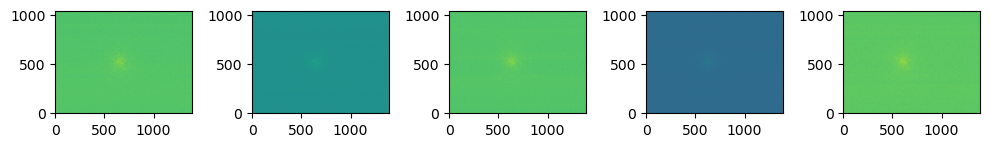

In [10]:
fig, ax = plt.subplots(1, 5, figsize = (10, 10))
for i, image_data in enumerate(all_data):
    im = ax[i].imshow(image_data, origin = "lower")

plt.tight_layout()
plt.show()

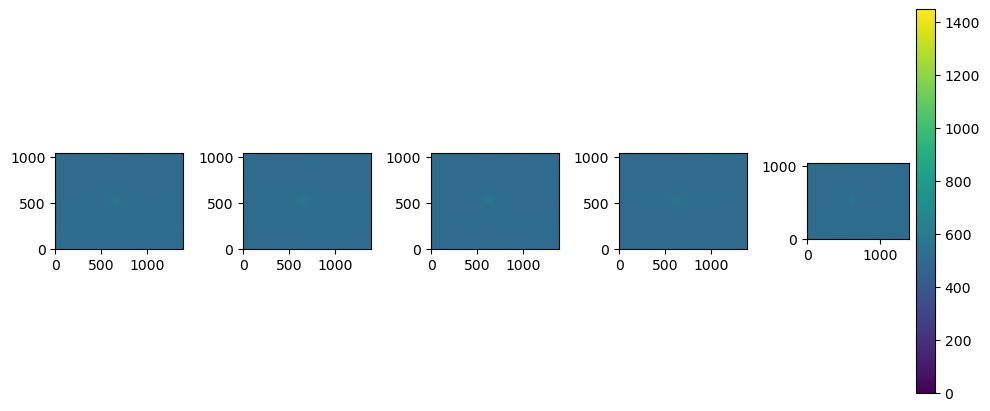

In [14]:
global_min = np.min([data.min() for data in all_data])
global_max = np.max([data.max() for data in all_data])

fig, ax = plt.subplots(1, 5, figsize = (10, 10))
for i, image_data in enumerate(all_data):
    im = ax[i].imshow(image_data, origin = "lower", vmin = global_min, vmax = global_max)
fig.colorbar(im)
plt.tight_layout()
plt.show()
# they're all the same color now

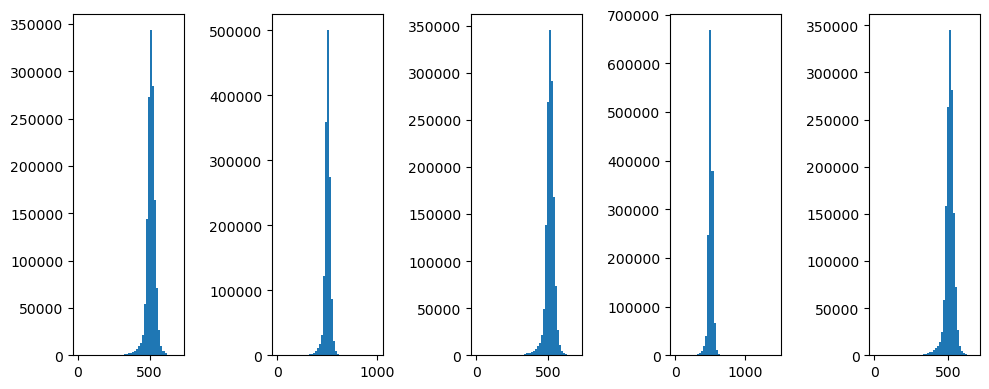

In [16]:
fig, ax = plt.subplots(1, 5, figsize = (10, 4))
for i, image_data in enumerate(all_data):
    pixel_values = image_data.ravel()
    ax[i].hist(pixel_values, bins = 50)
plt.tight_layout()
plt.show()
# the x label is the pixel value, the y label is the pixel frequency
# there are 50 intervals
# 500
# the data isn't very spread out

In [20]:
for i, image_data in enumerate(all_data):
    median_value = np.median(image_data)
print(median_value)

510.0


In [17]:
np.median(np.median(np.stack(all_data, axis = 0), axis = 0).ravel())

np.float64(510.0)

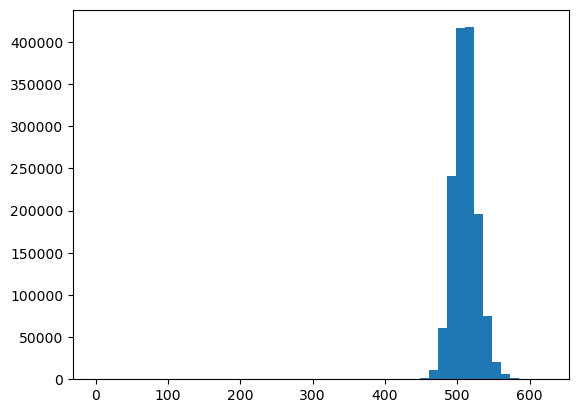

In [23]:
plt.figure()
plt.hist(np.median(np.stack(all_data, axis = 0), axis = 0).ravel(), bins = 50)
plt.show()

In [26]:
vmin = 460
vmax = 560
plt.figure(10, 10)
im = plt.imshow((np.median(np.stack(all_data, axis = 0), axis = 0)), origin = "lower", vmin = vmin, vmax = vmax)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [29]:
fits.writeto("combined.fits", combined_image, overwrite=True)

NameError: name 'combined_image' is not defined